In [1]:
from PIL import Image
import gradio as gr
import zipfile
import os
import numpy as np
import random
import shutil
import pandas as pd
import cv2
import sys
from scipy import ndimage

c:\Users\archi\anaconda3\envs\asid\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
HOME = os.path.expanduser('~') + '\\ecdna-analysis'

In [3]:
def find_counts(seg_I):
    """
        This function finds the number of nuclei, chromosomes, and ecDNA
        in segmented images.

        Input:
            seg_I: segmented image
        
        Output:
            in order: number of nuclei, chromosomes, and ecDNA
    """
    nuclei = (seg_I==1)
    chromosome = (seg_I==2)
    ecDNA = (seg_I==3)

    # Way we want to find connected components
    structure = np.ones((3, 3), dtype=int)

    # All the counts
    _, num_nuclei = ndimage.label(nuclei)
    _, num_chromosomes = ndimage.label(chromosome)
    _, num_ecDNA = ndimage.label(ecDNA)

    return [num_nuclei, num_chromosomes, num_ecDNA]


In [5]:
import os
import numpy as np

HOME = os.path.expanduser('~') + '\\ecdna-analysis\\'

test_bound = 2343
test_path = 'test_im_data\\labels'
train_bound = 9660
train_path = 'train_im_data\\labels'

with open(HOME + 'test_images_counts.csv', 'w') as f:
    f.write('image,num_nuclei,num_chromosomes,num_ecDNA\n')
    
    for image in os.listdir(HOME + test_path):
        if image.endswith('.npy'):
            seg_I = np.load(os.path.join(HOME + test_path, image))
            num_nuclei, num_chromosomes, num_ecDNA = find_counts(seg_I)
            f.write(f'{image[:-4]}.tif,{num_nuclei},{num_chromosomes},{num_ecDNA}\n')

f.close()

with open(HOME + 'train_images_counts.csv', 'w') as f:
    f.write('image,num_nuclei,num_chromosomes,num_ecDNA\n')
    for image in os.listdir(HOME + train_path):  # iterate over files, not range
        if image.endswith('.npy'):
            seg_I = np.load(os.path.join(HOME + train_path, image))
            num_nuclei, num_chromosomes, num_ecDNA = find_counts(seg_I)
            f.write(f'{image[:-4]}.tif,{num_nuclei},{num_chromosomes},{num_ecDNA}\n')

f.close()

In [9]:
num = 589
image = f'{num}.npy'
seg_I = np.load(os.path.join(HOME+test_path, image))
find_counts(seg_I)

[0, 9, 103]

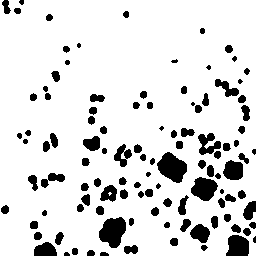

In [15]:
Image.fromarray(seg_I==0)